# RF-DETR Object Detection with OpenVINO

RF-DETR is a real-time transformer-based object detector built on a DINOv2 vision backbone and a deformable DETR decoder. This tutorial exports official [RF-DETR](https://github.com/roboflow/rf-detr) checkpoints to OpenVINO IR and runs object detection with the native OpenVINO API.

The default Nano model keeps the download and conversion practical. Small, Medium, Base, and Large variants can be selected for higher accuracy.

⚠️ **EXPERIMENTAL NOTEBOOK**

This notebook demonstrates the official RF-DETR OpenVINO exporter. The model variants and target devices have not all been validated in this notebook.

#### Table of contents:

- [Prerequisites](#Prerequisites)
- [Select a model](#Select-a-model)
- [Convert the model](#Convert-the-model)
- [Run object detection](#Run-object-detection)
- [Interactive demo](#Interactive-demo)

### References

- [RF-DETR paper](https://arxiv.org/abs/2511.09554)
- [RF-DETR repository](https://github.com/roboflow/rf-detr)
- [RF-DETR OpenVINO export guide](https://github.com/roboflow/rf-detr/blob/1.11.0/docs/exports/openvino.md)
- [OpenVINO documentation](https://docs.openvino.ai/)

<img referrerpolicy="no-referrer-when-downgrade" src="https://static.scarf.sh/a.png?x-pxid=5b5a4db0-7875-4bfb-bdbd-01698b5b1a77&file=notebooks/rf-detr-object-detection/rf-detr-object-detection.ipynb" />
### Installation Instructions

This is a self-contained example that relies solely on its own code.

We recommend  running the notebook in a virtual environment. You only need a Jupyter server to start.
For details, please refer to [Installation Guide](https://github.com/openvinotoolkit/openvino_notebooks/blob/latest/README.md#-installation-guide).

## Prerequisites
[back to top](#Table-of-contents)

Install the official RF-DETR package with its OpenVINO export support and the notebook demo dependencies.

In [1]:
from pathlib import Path

import requests

for helper_name in ("notebook_utils.py", "pip_helper.py"):
    helper_path = Path(helper_name)
    if not helper_path.exists():
        response = requests.get(
            f"https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/{helper_name}",
            timeout=30,
        )
        response.raise_for_status()
        helper_path.write_text(response.text, encoding="utf-8")

from pip_helper import pip_install

pip_install(
    "-q",
    "torch==2.10.0",
    "torchvision==0.25.0",
    "--extra-index-url",
    "https://download.pytorch.org/whl/cpu",
)
pip_install(
    "-q",
    "rfdetr[openvino]==1.11.0",
    "openvino>=2026.4",
    "transformers==5.17.0",
    "Pillow==11.3.0",
    "ipywidgets==8.1.9",
    "requests==2.34.2",
    "gradio==6.28.0",
)
# Read more about telemetry collection at https://github.com/openvinotoolkit/openvino_notebooks?tab=readme-ov-file#-telemetry
from notebook_utils import collect_telemetry

collect_telemetry("rf-detr-object-detection.ipynb")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
optimum-intel 2.3.0.dev0+348272d requires nncf>=3.3.0, but you have nncf 2.19.0 which is incompatible.
optimum-intel 2.3.0.dev0+348272d requires openvino>=2026.0, but you have openvino 2025.3.0 which is incompatible.
optimum-intel 2.3.0.dev0+348272d requires openvino-tokenizers>=2026.0, but you have openvino-tokenizers 2025.3.0.0 which is incompatible.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
llama-index-llms-huggingface 0.4.2 requires transformers[torch]<5.0.0,>=4.37.0, but you have transformers 5.17.0 which is incompatible.
optimum-intel 2.3.0.dev0+348272d requires nncf>=3.3.0, but you have nncf 2.19.0 which is incompatible.
optimum-intel 2.3.0.dev0+348272d requires openvino-tokenizers>=2026.0, but you have openvino-tokenizers 2025.3.0.0 which is incompatible.
optimum-intel 2.3.0.dev0+348272d requires transformers<5.11,>=4.51, but you have transformers 5.17.0 which is incompatible.
text-generation 0.7.0 requires huggingface-hub<1.0,>=0.12, but you have huggingface-hub 1.33.0 which is incompatible.
llama-index-embeddings-openvino 0.8.0 requires llama-index-core<0.15,>=0.13.0, but you have llama-index-core 0.12.52.post1 which is incompatible.
llama-index-embeddings-openvino 0.8.0 requires llama-index-e

In [2]:
from importlib.metadata import version

from notebook_utils import device_widget, download_file

print(f"RF-DETR version: {version('rfdetr')}")
print(f"OpenVINO version: {version('openvino')}")

IMAGE_PATH = Path("data/coco_bike.jpg")
if not IMAGE_PATH.exists():
    download_file(
        url="https://storage.openvinotoolkit.org/repositories/openvino_notebooks/data/data/image/coco_bike.jpg",
        filename=IMAGE_PATH.name,
        directory=IMAGE_PATH.parent,
    )

RF-DETR version: 1.11.0
OpenVINO version: 2026.4.1


coco_bike.jpg:   0%|          | 0.00/182k [00:00<?, ?B/s]

## Select a model
[back to top](#Table-of-contents)

The official RF-DETR checkpoints below use the Apache-2.0 license. The `rfdetr` package downloads the selected pretrained `.pth` checkpoint automatically. Nano is selected by default for a faster first run. Larger variants require more download time, memory, and conversion time.

| Variant | Export resolution |
|---|---:|
| Nano | 384 × 384 |
| Small | 512 × 512 |
| Medium | 576 × 576 |
| Base | 560 × 560 |
| Large | 704 × 704 |

The exporter validates the selected resolution against the model configuration. RF-DETR spatial dimensions must be divisible by `patch_size × num_windows`.

In [3]:
import ipywidgets as widgets
from IPython.display import display

MODEL_OPTIONS = [
    ("RF-DETR Nano (384 × 384)", ("nano", 384)),
    ("RF-DETR Small (512 × 512)", ("small", 512)),
    ("RF-DETR Medium (576 × 576)", ("medium", 576)),
    ("RF-DETR Base (560 × 560)", ("base", 560)),
    ("RF-DETR Large (704 × 704)", ("large", 704)),
]

model_selector = widgets.Dropdown(options=MODEL_OPTIONS, value=MODEL_OPTIONS[0][1], description="Model:")
device = device_widget(default="CPU", exclude=["NPU"])
display(model_selector, device)

Dropdown(description='Model:', options=(('RF-DETR Nano (384 × 384)', ('nano', 384)), ('RF-DETR Small (512 × 51…

Dropdown(description='Device:', options=('CPU', 'GPU', 'AUTO'), value='CPU')

## Convert the model
[back to top](#Table-of-contents)

`rfdetr` loads the selected pretrained checkpoint and exports it directly to OpenVINO IR with FP16-compressed weights. The `.xml` and `.bin` files are cached separately from any previous FP32 export in the local `model` directory and reused on subsequent runs. FP16 here controls weight storage; execution precision depends on the OpenVINO device. The IR has dynamic input dimensions; before compiling, we reshape it to batch size 1 and the selected model resolution.

In [4]:
import gc

import openvino as ov
from rfdetr import RFDETRBase, RFDETRLarge, RFDETRMedium, RFDETRNano, RFDETRSmall

MODEL_CLASSES = {
    "nano": RFDETRNano,
    "small": RFDETRSmall,
    "medium": RFDETRMedium,
    "base": RFDETRBase,
    "large": RFDETRLarge,
}
variant, resolution = model_selector.value
MODEL_DIR = Path("model") / f"rfdetr-{variant}-fp16-ov"
MODEL_PATH = MODEL_DIR / f"rfdetr-{variant}.xml"

if not MODEL_PATH.exists() or not MODEL_PATH.with_suffix(".bin").exists():
    print(f"Converting RF-DETR {variant} to OpenVINO IR...")
    detector = MODEL_CLASSES[variant]()
    exported_path = detector.export(
        format="openvino",
        output_dir=str(MODEL_DIR),
        output_name=f"rfdetr-{variant}",
        shape=(resolution, resolution),
        openvino_precision="float16",
    )
    if Path(exported_path).resolve() != MODEL_PATH.resolve():
        raise RuntimeError(f"Unexpected export path: {exported_path}")
    del detector
    gc.collect()
else:
    print(f"Using cached OpenVINO model from {MODEL_DIR}")

core = ov.Core()
ir_model = core.read_model(MODEL_PATH)
ir_model.reshape({ir_model.input(0): [1, 3, resolution, resolution]})
ov_model = core.compile_model(ir_model, device.value)
print(f"Loaded RF-DETR {variant} on {device.value}")

Converting RF-DETR nano to OpenVINO IR...
[2026-10-06 07:08:25] [INFO] rf-detr - Downloading pretrained weights for /home/amd/.roboflow/models/rf-detr-nano.pth


/home/amd/.roboflow/models/rf-detr-nano.pth:   0%|          | 0.00/349M [00:00<?, ?iB/s]

[2026-10-06 07:08:48] [INFO] rf-detr - MD5 validation successful for /home/amd/.roboflow/models/rf-detr-nano.pth


[2026-10-06 07:08:48] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-10-06 07:08:48] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


...

/home/amd/Desktop/OpenVINO-Notebooks-on-AMD/.venvs/cpu/14c79f40de9d556c/lib/python3.12/site-packages/rfdetr/models/transformer.py:731: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  topk = min(self.num_queries, enc_outputs_class_unselected_gidx.shape[-2])
/home/amd/Desktop/OpenVINO-Notebooks-on-AMD/.venvs/cpu/14c79f40de9d556c/lib/python3.12/site-packages/rfdetr/models/transformer.py:90: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if pos_tensor.size(-1) == 2:
/home/amd/Desktop/OpenVINO-Notebooks-on-AMD/.venvs/cpu/14c79f40de9d556c/lib/python3.12/site-pa

[2026-10-06 07:08:53] [INFO] rf-detr - ✓ OpenVINO IR model saved to model/rfdetr-nano-fp16-ov/rfdetr-nano.xml


[2026-10-06 07:08:53] [INFO] rf-detr - ✓ Model binary saved to model/rfdetr-nano-fp16-ov/rfdetr-nano.bin


[2026-10-06 07:08:53] [INFO] rf-detr - Successfully exported OpenVINO model to: model/rfdetr-nano-fp16-ov/rfdetr-nano.xml


Loaded RF-DETR nano on CPU


## Run object detection
[back to top](#Table-of-contents)

Preprocessing matches the resize and normalization used by `rfdetr.predict()`; inference runs through the native OpenVINO API. The exported model returns normalized center-format boxes and raw class logits. Postprocessing applies per-class sigmoid, selects the highest-scoring query/class pairs, and converts boxes into pixel coordinates.

In [5]:
confidence_threshold = widgets.FloatSlider(
    value=0.4,
    min=0.05,
    max=0.95,
    step=0.05,
    description="Threshold:",
    readout_format=".2f",
)
confidence_threshold

FloatSlider(value=0.4, description='Threshold:', max=0.95, min=0.05, step=0.05)

Detected 5 objects with confidence >= 0.40


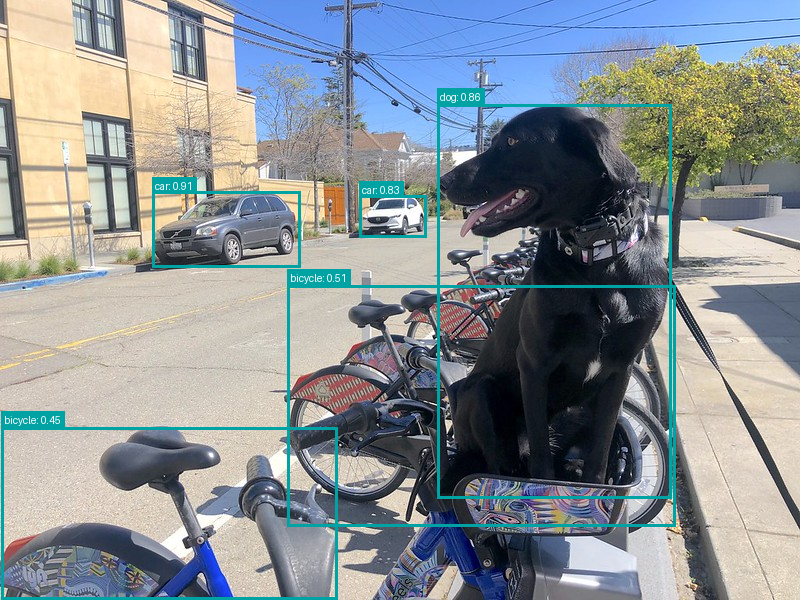

In [6]:
from gradio_helper import run_object_detection
from PIL import Image

image = Image.open(IMAGE_PATH)
visualization, detections = run_object_detection(
    ov_model,
    image,
    confidence_threshold.value,
)

print(f"Detected {len(detections)} objects with confidence >= {confidence_threshold.value:.2f}")
visualization

## Interactive demo
[back to top](#Table-of-contents)

Upload an image and adjust the confidence threshold to run RF-DETR interactively with the selected OpenVINO device.